In [1]:
# fetching data 
from datasets import load_dataset
import torch

d:\DeepLearning\Sammili\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = load_dataset("Abdullah-afify/egyptian-names")

'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/Abdullah-afify/egyptian-names/resolve/2a9cf6419177935e38821f3db7b085606d945618/egyptian-names.py
Retrying in 1s [Retry 1/5].


In [3]:
data

DatasetDict({
    train: Dataset({
        features: ['name_ar', 'name_en', 'gender', 'religion', 'role', 'ar_variants', 'en_variants', 'slot1_pct', 'slot2_pct', 'slot3_pct', 'slot4_pct', 'slot5_pct', 'slot6_pct', 'slot7_pct', 'slot8_pct', 'corpus_share_pct', 'frequency_class', 'tashkeel_standard', 'tashkeel_eg', 'tashkeel', 'ipa_standard', 'ipa_eg', 'meaning_ar', 'meaning_en', 'dallaa', 'dallaa_ar', 'dallaa_tashkeel', 'dallaa_en', 'dallaa_ipa', 'root', 'origin_type', 'famous_figures', 'famous_figures_ar', 'famous_figures_en', 'trend_category', 'is_personal_name', 'is_low_confidence'],
        num_rows: 44626
    })
})

In [4]:
data["train"]["name_ar"][:10]

['محمد',
 'أحمد',
 'علي',
 'محمود',
 'إبراهيم',
 'السيد',
 'حسن',
 'مصطفى',
 'يوسف',
 'عبدالله']

In [5]:
names = list(data["train"]["name_ar"])
listed_names= [] 
for name in names:
    listed_names.append(list(name))

def to_set(li):
    return set("".join("".join(name) for name in li))
chars = to_set(listed_names)
len(chars)

38

In [6]:
# normalizing the names to remove diacritics and punctuation
normalize_map = str.maketrans({
    'أ': 'ا', 'إ': 'ا', 'آ': 'ا',
    'ة': 'ه',
})

names = [n.translate(normalize_map) for n in names]
len(to_set(names))

34

In [7]:
with open("names.txt", "w", encoding="utf-8") as f:
    for name in names:
        f.write(name + "\n")

In [8]:
test = ['<ب>'] + list(names[0]) + ['<ن>']
test

['<ب>', 'م', 'ح', 'م', 'د', '<ن>']

In [9]:
print(test[0],test[1],test[-1])

<ب> م <ن>


In [10]:
len(names)

44626

## bigram model

In [11]:

# adding start and end tokens to the names
for i in range(len(names)):
    names[i] = ['<ب>'] + list(names[i]) + ['<ن>']

names[:10]

[['<ب>', 'م', 'ح', 'م', 'د', '<ن>'],
 ['<ب>', 'ا', 'ح', 'م', 'د', '<ن>'],
 ['<ب>', 'ع', 'ل', 'ي', '<ن>'],
 ['<ب>', 'م', 'ح', 'م', 'و', 'د', '<ن>'],
 ['<ب>', 'ا', 'ب', 'ر', 'ا', 'ه', 'ي', 'م', '<ن>'],
 ['<ب>', 'ا', 'ل', 'س', 'ي', 'د', '<ن>'],
 ['<ب>', 'ح', 'س', 'ن', '<ن>'],
 ['<ب>', 'م', 'ص', 'ط', 'ف', 'ى', '<ن>'],
 ['<ب>', 'ي', 'و', 'س', 'ف', '<ن>'],
 ['<ب>', 'ع', 'ب', 'د', 'ا', 'ل', 'ل', 'ه', '<ن>']]

In [12]:
#dictionary of characters
seq = {}
for name in names:
    for ch1,ch2 in zip(name ,name[1:]):
        bigram = (ch1,ch2)
        seq[bigram] = seq.get((ch1,ch2),0) + 1
        

In [13]:
seq

{('<ب>', 'م'): 3450,
 ('م', 'ح'): 450,
 ('ح', 'م'): 704,
 ('م', 'د'): 542,
 ('د', '<ن>'): 1596,
 ('<ب>', 'ا'): 17214,
 ('ا', 'ح'): 517,
 ('<ب>', 'ع'): 2532,
 ('ع', 'ل'): 353,
 ('ل', 'ي'): 2372,
 ('ي', '<ن>'): 9468,
 ('م', 'و'): 838,
 ('و', 'د'): 752,
 ('ا', 'ب'): 4219,
 ('ب', 'ر'): 1045,
 ('ر', 'ا'): 2233,
 ('ا', 'ه'): 481,
 ('ه', 'ي'): 637,
 ('ي', 'م'): 1038,
 ('م', '<ن>'): 1630,
 ('ا', 'ل'): 15568,
 ('ل', 'س'): 994,
 ('س', 'ي'): 1359,
 ('ي', 'د'): 1319,
 ('<ب>', 'ح'): 1250,
 ('ح', 'س'): 249,
 ('س', 'ن'): 438,
 ('ن', '<ن>'): 3901,
 ('م', 'ص'): 145,
 ('ص', 'ط'): 45,
 ('ط', 'ف'): 87,
 ('ف', 'ى'): 92,
 ('ى', '<ن>'): 2340,
 ('<ب>', 'ي'): 368,
 ('ي', 'و'): 873,
 ('و', 'س'): 1146,
 ('س', 'ف'): 88,
 ('ف', '<ن>'): 684,
 ('ع', 'ب'): 1451,
 ('ب', 'د'): 1436,
 ('د', 'ا'): 2295,
 ('ل', 'ل'): 794,
 ('ل', 'ه'): 1458,
 ('ه', '<ن>'): 7263,
 ('ل', 'ر'): 526,
 ('ر', 'ح'): 269,
 ('م', 'ن'): 740,
 ('<ب>', 'س'): 1626,
 ('ي', 'ن'): 2385,
 ('ل', 'ح'): 933,
 ('م', 'ي'): 1673,
 ('م', 'ر'): 879,
 ('ر', 'ي'): 3

In [21]:
flat = [ch for name in names for ch in name]
ch_dict = {ch:i for i,ch in enumerate(sorted(set(flat)))}
len(ch_dict)

36

In [20]:
arr = torch.zeros((36,36) , dtype=torch.int32)


In [23]:
test_li = [['a','b','c'],['d','e','f']]
print("".join("".join(name) for name in test_li))

abcdef


In [24]:
for k,v in seq.items():
    i = ch_dict[k[0]]
    j = ch_dict[k[1]]
    arr[i,j] = v

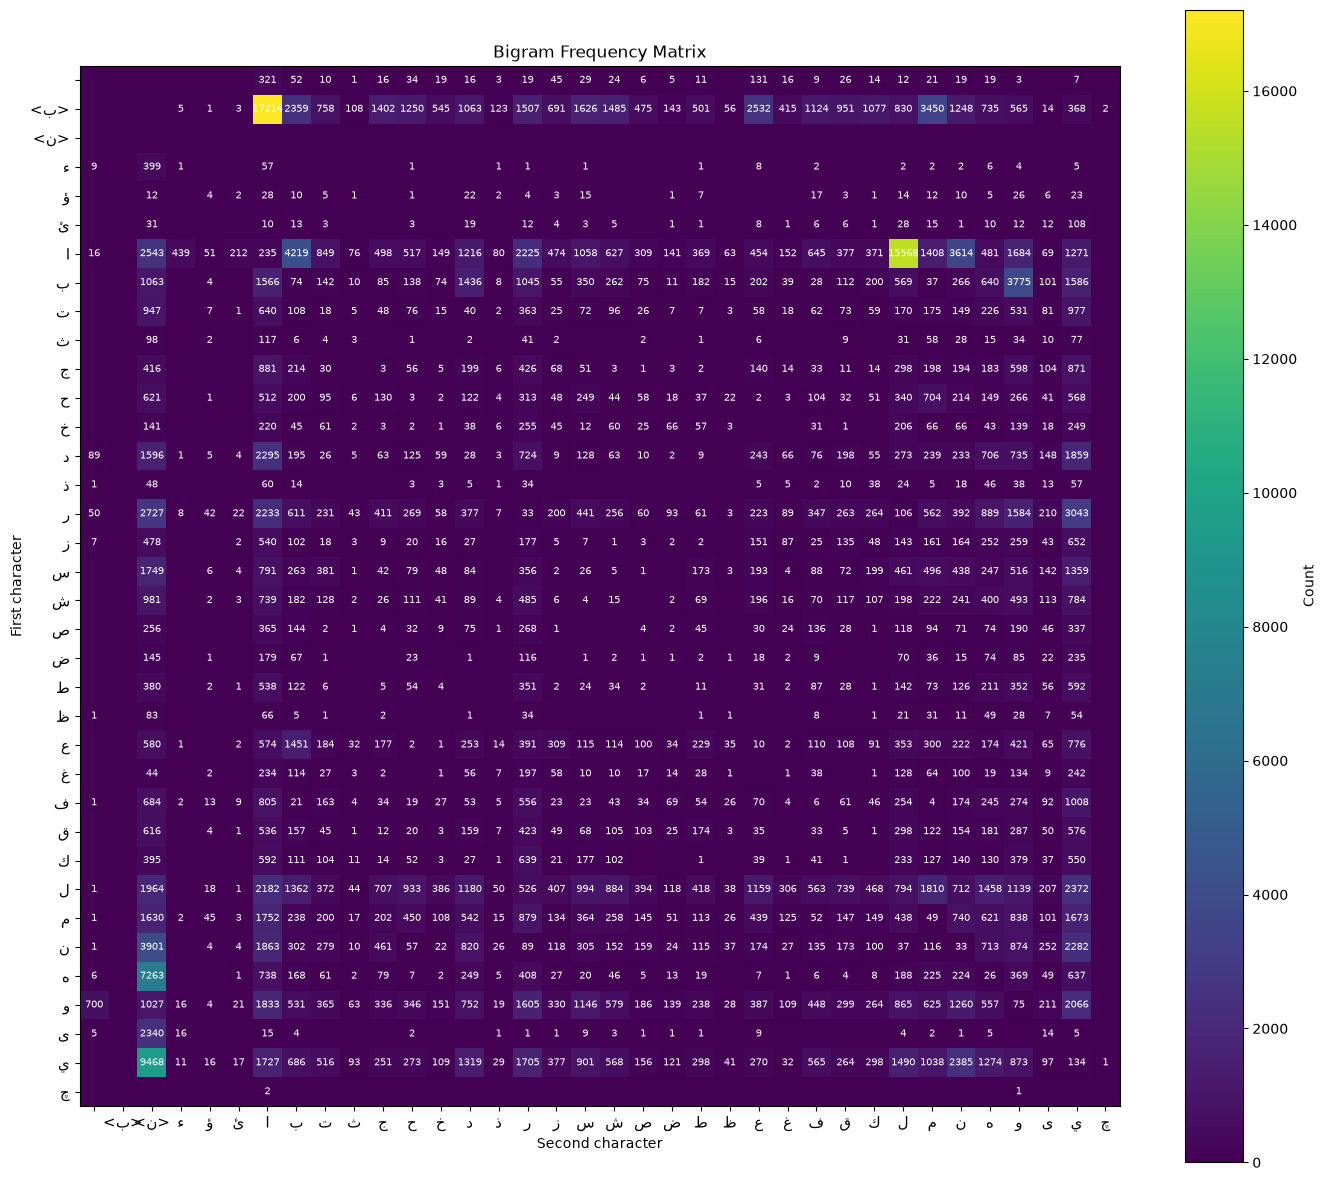

In [28]:
# visualizing the bigram counts
import matplotlib.pyplot as plt

labels = [ch for ch, _ in sorted(ch_dict.items(), key=lambda item: item[1])]
fig, ax = plt.subplots(figsize=(14, 12))
image = ax.imshow(arr.numpy(), cmap="viridis", aspect="equal")

ax.set_title("Bigram Frequency Matrix")
ax.set_xlabel("Second character")
ax.set_ylabel("First character")
ax.set_xticks(range(len(labels)), labels=labels)
ax.set_yticks(range(len(labels)), labels=labels)
ax.tick_params(axis="both", labelsize=11)

for row, column in arr.nonzero().tolist():
    count = int(arr[row, column])
    ax.text(column, row, count, ha="center", va="center", fontsize=7, color="white")

fig.colorbar(image, ax=ax, label="Count")
fig.tight_layout()
plt.show()